In [1]:
import watermark
pkg_versions = watermark.watermark(
    packages="requests,pandas,tqdm,geopandas")
print(pkg_versions)

requests : 2.32.5
pandas   : 1.5.3
tqdm     : 4.67.1
geopandas: 1.0.1



In [2]:
import pandas as pd
df = pd.read_csv("구군별 관광지 수.csv")

In [3]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = "/home/DL/.local/share/fonts/KoPubWorld/KoPubWorld Dotum Medium.ttf"

# 현재 Python 프로세스에 폰트 등록
fm.fontManager.addfont(font_path)

font_name = fm.FontProperties(fname=font_path).get_name()
print(font_name)

plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False

KoPubWorldDotum


In [5]:
import geopandas as gpd

In [6]:
gdf = gpd.read_file("../sigungu/sig.shp", encoding="cp949")
gdf = gdf.set_crs(epsg=5179)
gdf = gdf.to_crs(4326)
gdf = gdf[[i[:2]=="26" for i in gdf["SIG_CD"]]].reset_index(drop=True)

In [7]:
gdf = gdf.merge(df, right_on = "구군", left_on="SIG_KOR_NM")
gdf

,SIG_CD,SIG_ENG_NM,SIG_KOR_NM,geometry,구군,관광지수
0,26110,Jung-gu,중구,"POLYGON ((129.03231 35.11643, 129.03235 35.116...",중구,190
1,26140,Seo-gu,서구,"MULTIPOLYGON (((129.01542 35.04808, 129.01515 ...",서구,50
2,26170,Dong-gu,동구,"POLYGON ((129.04264 35.14589, 129.04327 35.145...",동구,101
3,26200,Yeongdo-gu,영도구,"MULTIPOLYGON (((129.0932 35.03771, 129.09324 3...",영도구,81
4,26230,Busanjin-gu,부산진구,"POLYGON ((129.04001 35.19981, 129.04033 35.199...",부산진구,288
5,26260,Dongnae-gu,동래구,"POLYGON ((129.07905 35.22509, 129.0791 35.2250...",동래구,80
6,26290,Nam-gu,남구,"MULTIPOLYGON (((129.12702 35.09096, 129.12697 ...",남구,75
7,26320,Buk-gu,북구,"POLYGON ((128.98774 35.20145, 128.98774 35.201...",북구,29
8,26350,Haeundae-gu,해운대구,"MULTIPOLYGON (((129.13898 35.1586, 129.13963 3...",해운대구,331
9,26380,Saha-gu,사하구,"MULTIPOLYGON (((128.95195 34.88449, 128.95194 ...",사하구,77


In [8]:
gdf

,SIG_CD,SIG_ENG_NM,SIG_KOR_NM,geometry,구군,관광지수
0,26110,Jung-gu,중구,"POLYGON ((129.03231 35.11643, 129.03235 35.116...",중구,190
1,26140,Seo-gu,서구,"MULTIPOLYGON (((129.01542 35.04808, 129.01515 ...",서구,50
2,26170,Dong-gu,동구,"POLYGON ((129.04264 35.14589, 129.04327 35.145...",동구,101
3,26200,Yeongdo-gu,영도구,"MULTIPOLYGON (((129.0932 35.03771, 129.09324 3...",영도구,81
4,26230,Busanjin-gu,부산진구,"POLYGON ((129.04001 35.19981, 129.04033 35.199...",부산진구,288
5,26260,Dongnae-gu,동래구,"POLYGON ((129.07905 35.22509, 129.0791 35.2250...",동래구,80
6,26290,Nam-gu,남구,"MULTIPOLYGON (((129.12702 35.09096, 129.12697 ...",남구,75
7,26320,Buk-gu,북구,"POLYGON ((128.98774 35.20145, 128.98774 35.201...",북구,29
8,26350,Haeundae-gu,해운대구,"MULTIPOLYGON (((129.13898 35.1586, 129.13963 3...",해운대구,331
9,26380,Saha-gu,사하구,"MULTIPOLYGON (((128.95195 34.88449, 128.95194 ...",사하구,77


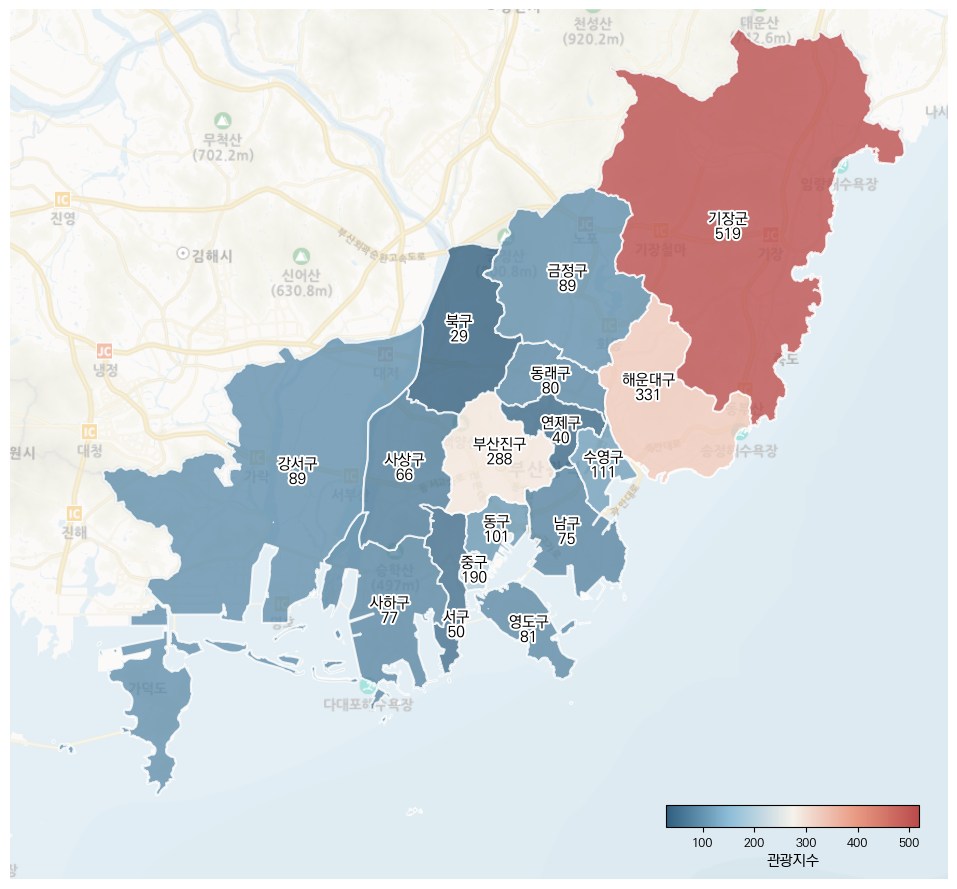

In [18]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import contextily as ctx
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable

cmap = LinearSegmentedColormap.from_list(
    "tour", ["#2F5D7E", "#8DBDD8", "#F5F2EB", "#E99A83", "#B94B4B"]
)

m = gdf.to_crs(3857)
fig, ax = plt.subplots(figsize=(15, 9))

m.plot(
    column="관광지수", cmap=cmap, alpha=.78,
    edgecolor="white", linewidth=1.5, ax=ax
)

ctx.add_basemap(
    ax,
    source="https://xdworld.vworld.kr/2d/Base/service/{z}/{x}/{y}.png",
    alpha=.35
)

# 아래쪽 잘라내기
xmin, ymin, xmax, ymax = m.total_bounds
H = ymax - ymin
ax.set_ylim(ymin + H*.12, ymax + H*.02)

# 라벨
for _, r in m.iterrows():
    p = r.geometry.representative_point()
    dy = -2500 if r["구군"] == "서구" else 0

    t = ax.text(
        p.x, p.y + dy,
        f'{r["구군"]}\n{r["관광지수"]}',
        ha="center", va="center",
        fontsize=11, weight="bold"
    )
    t.set_path_effects([
        pe.Stroke(linewidth=3, foreground="white"),
        pe.Normal()
    ])

# 좌측 상단 가로 컬러바
norm = Normalize(m["관광지수"].min(), m["관광지수"].max())
sm = ScalarMappable(norm=norm, cmap=cmap)

cax = ax.inset_axes([
    .70,   # x
    .06,   # y
    .27,   # width
    .025   # height
])
cbar = fig.colorbar(sm, cax=cax, orientation="horizontal")
cbar.set_label("관광지수", fontsize=11, weight="bold")
cbar.ax.tick_params(labelsize=9)

ax.axis("off")
plt.tight_layout()
plt.savefig(
    "부산_관광지수_지도.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()